# Phase-5b: Risk-Score-Only Clustering

**Goal:** Cluster London LSOAs into priority tiers using only the composite risk score built in Phase 4.

**Rationale:** The risk index already incorporates all 6 validated features with empirically derived weights. Clustering on the score alone avoids redundancy and produces tiers that are directly ordered by policing demand cleaner and more defensible for stakeholder communication.

**Method:** Same as Phase-5: K-Means (k=2 to 6) validated by silhouette score + GMM AIC/BIC cross-validation.

**Outputs saved to:** `outputs/phase5b/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path
from collections import Counter

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, silhouette_samples

print('Imports OK')

Imports OK


In [ ]:
BASE = Path('Dataset')
P4   = BASE / 'outputs' / 'phase4'
OUT  = BASE / 'outputs' / 'phase5b'
OUT.mkdir(parents=True, exist_ok=True)
print('Output folder:', OUT)

Output folder: C:\Users\mbeck\OneDrive\Documents\CBL-16_data\outputs\phase5b


## Section-1: Load Data

In [3]:
risk = pd.read_parquet(P4 / 'phase4_risk_scores.parquet')
print(f'Loaded: {risk.shape}')
print(f'Risk score range: {risk["risk_score_scaled"].min():.2f} – {risk["risk_score_scaled"].max():.2f}')
print(f'Mean: {risk["risk_score_scaled"].mean():.2f}  Std: {risk["risk_score_scaled"].std():.2f}')

# Single feature array — risk score only
X = risk[['risk_score_scaled']].values  # shape (4994, 1)
print(f'\nClustering input shape: {X.shape}  (risk score only)')

Loaded: (4994, 14)
Risk score range: 0.00 – 100.00
Mean: 52.62  Std: 5.53

Clustering input shape: (4994, 1)  (risk score only)


## Section-2: K-Means + Silhouette (k=2 to 6)

In [4]:
k_range = range(2, 7)
inertias    = []
silhouettes = []
km_models   = {}

print('Testing K-Means (risk score only) for k=2 to 6...')
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500)
    labels = km.fit_predict(X)
    inertia = km.inertia_
    sil     = silhouette_score(X, labels)
    inertias.append(inertia)
    silhouettes.append(sil)
    km_models[k] = (km, labels)
    # Print cluster centroids (actual risk score values)
    centres = sorted(km.cluster_centers_.flatten())
    print(f'  k={k}  silhouette={sil:.4f}  inertia={inertia:.1f}  centroids={[round(c,1) for c in centres]}')

best_k_sil = list(k_range)[np.argmax(silhouettes)]
print(f'\nBest k by silhouette: {best_k_sil}')

Testing K-Means (risk score only) for k=2 to 6...
  k=2  silhouette=0.5328  inertia=77965.8  centroids=[np.float64(48.2), np.float64(56.0)]
  k=3  silhouette=0.5361  inertia=49896.3  centroids=[np.float64(2.1), np.float64(48.8), np.float64(56.3)]
  k=4  silhouette=0.5449  inertia=27313.5  centroids=[np.float64(2.1), np.float64(47.5), np.float64(53.7), np.float64(60.4)]
  k=5  silhouette=0.5302  inertia=17582.5  centroids=[np.float64(2.1), np.float64(46.5), np.float64(51.7), np.float64(56.0), np.float64(63.1)]
  k=6  silhouette=0.5233  inertia=12686.5  centroids=[np.float64(2.1), np.float64(45.8), np.float64(50.2), np.float64(53.9), np.float64(57.8), np.float64(65.0)]

Best k by silhouette: 4


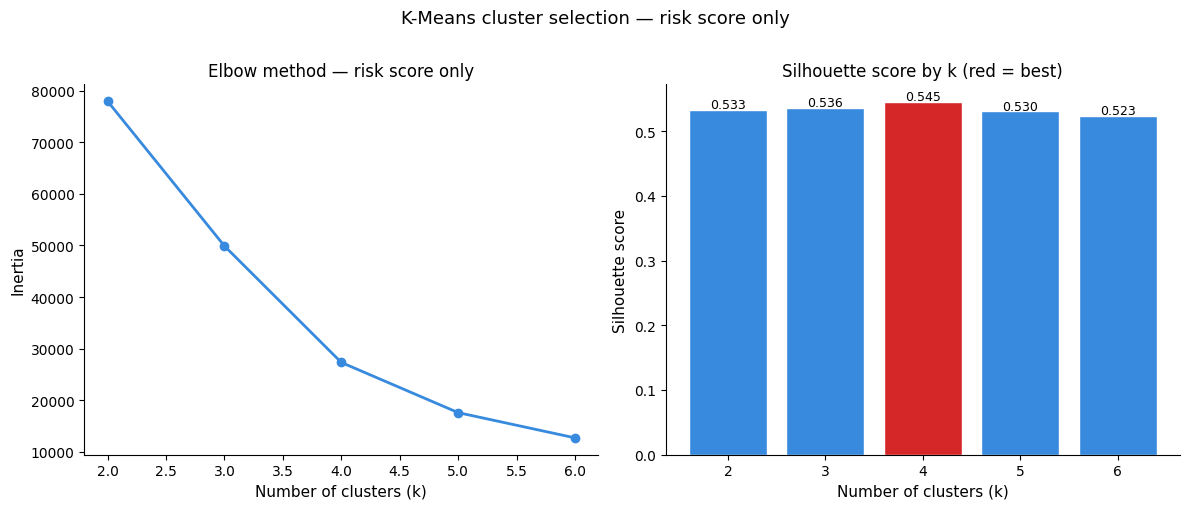

Saved: 5b_silhouette.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Elbow
axes[0].plot(list(k_range), inertias, 'o-', color='#378ADD', linewidth=2)
axes[0].set_xlabel('Number of clusters (k)', fontsize=11)
axes[0].set_ylabel('Inertia', fontsize=11)
axes[0].set_title('Elbow method — risk score only', fontsize=12)
axes[0].spines[['top','right']].set_visible(False)

# Silhouette
colours = ['#D62728' if k == best_k_sil else '#378ADD' for k in k_range]
bars = axes[1].bar(list(k_range), silhouettes, color=colours, edgecolor='white')
axes[1].set_xlabel('Number of clusters (k)', fontsize=11)
axes[1].set_ylabel('Silhouette score', fontsize=11)
axes[1].set_title('Silhouette score by k (red = best)', fontsize=12)
axes[1].spines[['top','right']].set_visible(False)
for bar, sil in zip(bars, silhouettes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{sil:.3f}', ha='center', fontsize=9)

plt.suptitle('K-Means cluster selection — risk score only', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(OUT / '5b_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 5b_silhouette.png')

## Section-3: GMM AIC/BIC Cross-Validation

In [6]:
aics, bics = [], []
gmm_models = {}

print('Fitting GMM for k=2 to 6...')
for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=10, max_iter=300)
    gmm.fit(X)
    aics.append(gmm.aic(X))
    bics.append(gmm.bic(X))
    gmm_models[k] = gmm
    print(f'  k={k}  AIC={gmm.aic(X):.1f}  BIC={gmm.bic(X):.1f}')

best_k_aic = list(k_range)[np.argmin(aics)]
best_k_bic = list(k_range)[np.argmin(bics)]
print(f'\nBest k — AIC: {best_k_aic}  |  BIC: {best_k_bic}')

Fitting GMM for k=2 to 6...
  k=2  AIC=30047.7  BIC=30080.3
  k=3  AIC=29976.6  BIC=30028.8
  k=4  AIC=29900.8  BIC=29972.5
  k=5  AIC=29924.0  BIC=30015.2
  k=6  AIC=29883.6  BIC=29994.4

Best k — AIC: 6  |  BIC: 4


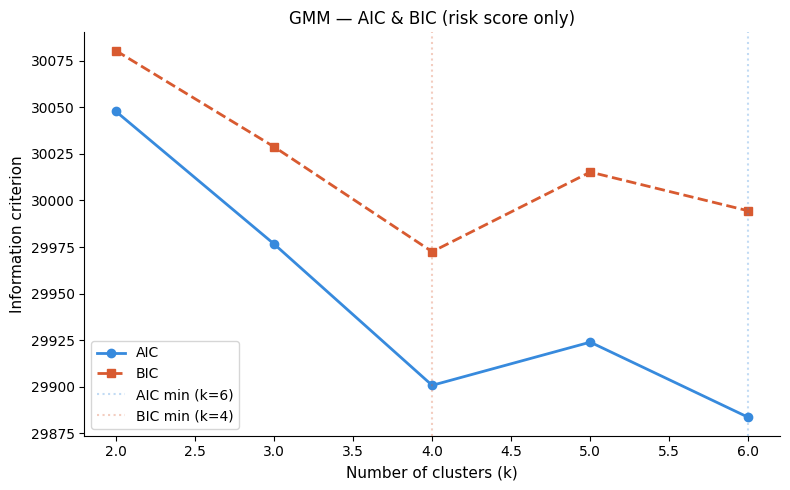

Saved: 5b_gmm_criteria.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(k_range), aics, 'o-', color='#378ADD', linewidth=2, label='AIC')
ax.plot(list(k_range), bics, 's--', color='#D85A30', linewidth=2, label='BIC')
ax.axvline(best_k_aic, color='#378ADD', alpha=0.3, linestyle=':', label=f'AIC min (k={best_k_aic})')
ax.axvline(best_k_bic, color='#D85A30', alpha=0.3, linestyle=':', label=f'BIC min (k={best_k_bic})')
ax.set_xlabel('Number of clusters (k)', fontsize=11)
ax.set_ylabel('Information criterion', fontsize=11)
ax.set_title('GMM — AIC & BIC (risk score only)', fontsize=12)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / '5b_gmm_criteria.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 5b_gmm_criteria.png')

## Section-4: Select Final k & Assign Tier Labels

In [8]:
# Majority vote across silhouette, AIC, BIC
votes = [best_k_sil, best_k_aic, best_k_bic]
vote_counts = Counter(votes)
FINAL_K = vote_counts.most_common(1)[0][0]
if vote_counts.most_common(1)[0][1] == 1:
    FINAL_K = best_k_sil  # silhouette wins tiebreak

print(f'Silhouette best k : {best_k_sil}')
print(f'AIC best k        : {best_k_aic}')
print(f'BIC best k        : {best_k_bic}')
print(f'\n>>> FINAL k = {FINAL_K} <<<')

# Assign labels
final_km, final_labels = km_models[FINAL_K]
risk['cluster_raw'] = final_labels

# Order clusters by mean risk score → Tier 1 = highest risk
cluster_means = (
    risk.groupby('cluster_raw')['risk_score_scaled']
    .mean().sort_values(ascending=False).reset_index()
)
cluster_means['tier'] = range(1, FINAL_K + 1)
tier_map = dict(zip(cluster_means['cluster_raw'], cluster_means['tier']))
risk['tier'] = risk['cluster_raw'].map(tier_map)

print('\nCluster centroids and tier assignment:')
centres = final_km.cluster_centers_.flatten()
for raw, row in cluster_means.iterrows():
    centre = centres[int(row['cluster_raw'])]
    print(f"  cluster_raw={int(row['cluster_raw'])}  centroid={centre:.2f}  → Tier {int(row['tier'])}")

print('\nLSOAs per tier:')
print(risk['tier'].value_counts().sort_index())

Silhouette best k : 4
AIC best k        : 6
BIC best k        : 4

>>> FINAL k = 4 <<<

Cluster centroids and tier assignment:
  cluster_raw=0  centroid=60.37  → Tier 1
  cluster_raw=3  centroid=53.72  → Tier 2
  cluster_raw=2  centroid=47.51  → Tier 3
  cluster_raw=1  centroid=2.13  → Tier 4

LSOAs per tier:
tier
1     777
2    2585
3    1619
4      13
Name: count, dtype: int64


In [9]:
# Define tier labels based on final k
ALL_TIER_LABELS = {
    2: {1: 'High Risk',    2: 'Low Risk'},
    3: {1: 'High Risk',    2: 'Moderate Risk', 3: 'Low Risk'},
    4: {1: 'High Risk',    2: 'Elevated Risk', 3: 'Moderate Risk', 4: 'Low Risk'},
    5: {1: 'Critical Risk',2: 'High Risk',     3: 'Elevated Risk', 4: 'Moderate Risk', 5: 'Low Risk'},
    6: {1: 'Critical Risk',2: 'High Risk',     3: 'Elevated Risk', 4: 'Moderate Risk', 5: 'Low Risk', 6: 'Minimal Risk'},
}
TIER_LABELS = ALL_TIER_LABELS[FINAL_K]

ALL_TIER_COLOURS = {
    2: {1: '#D62728', 2: '#2CA02C'},
    3: {1: '#D62728', 2: '#FF7F0E', 3: '#2CA02C'},
    4: {1: '#D62728', 2: '#FF7F0E', 3: '#2CA02C', 4: '#1F77B4'},
    5: {1: '#8B0000', 2: '#D62728', 3: '#FF7F0E', 4: '#2CA02C', 5: '#1F77B4'},
    6: {1: '#8B0000', 2: '#D62728', 3: '#FF7F0E', 4: '#2CA02C', 5: '#1F77B4', 6: '#9467BD'},
}
TIER_COLOURS = ALL_TIER_COLOURS[FINAL_K]

risk['tier_label'] = risk['tier'].map(TIER_LABELS)

print('Tier labels:')
for t in sorted(TIER_LABELS):
    n   = (risk['tier'] == t).sum()
    pct = n / len(risk) * 100
    rs_mean = risk[risk['tier']==t]['risk_score_scaled'].mean()
    rs_min  = risk[risk['tier']==t]['risk_score_scaled'].min()
    rs_max  = risk[risk['tier']==t]['risk_score_scaled'].max()
    print(f'  Tier {t} — {TIER_LABELS[t]:<16} n={n:5d} ({pct:4.1f}%)  score range: {rs_min:.1f}–{rs_max:.1f}  mean={rs_mean:.1f}')

Tier labels:
  Tier 1 — High Risk        n=  777 (15.6%)  score range: 57.0–100.0  mean=60.4
  Tier 2 — Elevated Risk    n= 2585 (51.8%)  score range: 50.6–57.0  mean=53.7
  Tier 3 — Moderate Risk    n= 1619 (32.4%)  score range: 38.1–50.6  mean=47.5
  Tier 4 — Low Risk         n=   13 ( 0.3%)  score range: 0.0–4.9  mean=2.1


## Section-5: Visualisations

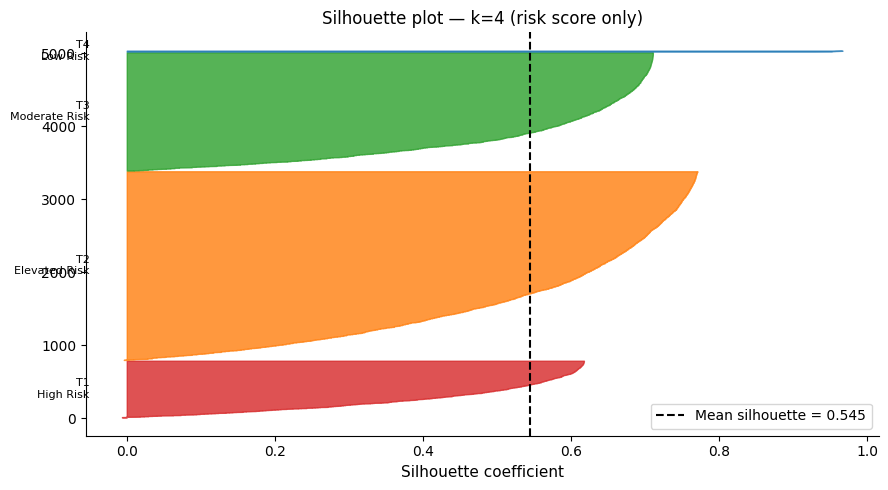

Saved: 5b_silhouette_detail.png


In [10]:
# Silhouette detail plot
sil_vals = silhouette_samples(X, final_labels)
risk['silhouette'] = sil_vals
overall_sil = silhouette_score(X, final_labels)

fig, ax = plt.subplots(figsize=(9, 5))
y_lower = 10
for tier in sorted(risk['tier'].unique()):
    colour = TIER_COLOURS[tier]
    mask = risk['tier'] == tier
    tier_sil = np.sort(sil_vals[mask.values])
    y_upper = y_lower + len(tier_sil)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, tier_sil,
                     facecolor=colour, edgecolor=colour, alpha=0.8)
    ax.text(-0.05, y_lower + len(tier_sil)/2,
            f'T{tier}\n{TIER_LABELS[tier]}', ha='right', va='center', fontsize=8)
    y_lower = y_upper + 10

ax.axvline(overall_sil, color='black', linestyle='--', linewidth=1.5,
           label=f'Mean silhouette = {overall_sil:.3f}')
ax.set_xlabel('Silhouette coefficient', fontsize=11)
ax.set_title(f'Silhouette plot — k={FINAL_K} (risk score only)', fontsize=12)
ax.legend(fontsize=10)
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / '5b_silhouette_detail.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 5b_silhouette_detail.png')

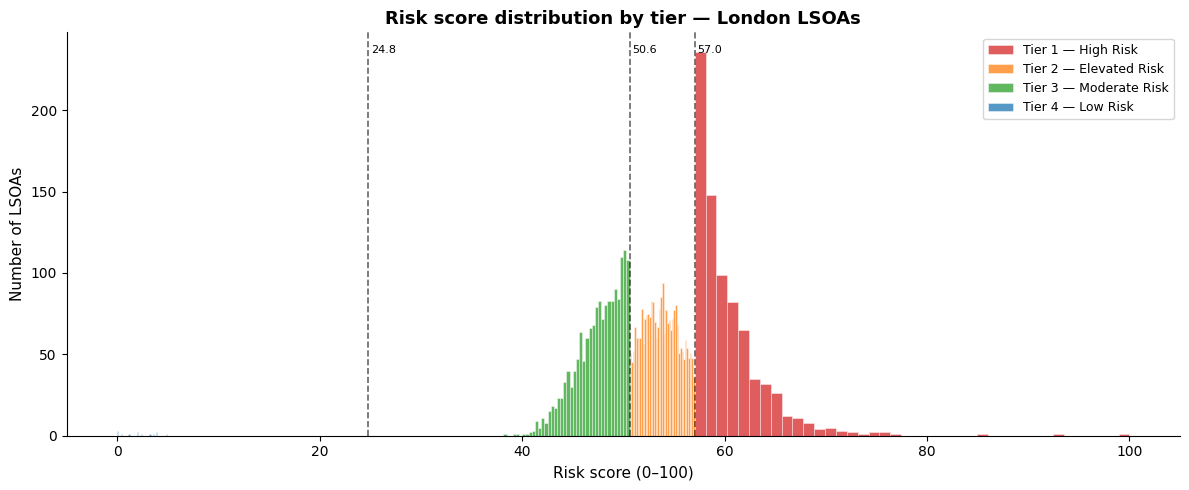

Saved: 5b_score_distribution.png


In [11]:
# Risk score distribution coloured by tier
fig, ax = plt.subplots(figsize=(12, 5))

for tier in sorted(risk['tier'].unique()):
    subset = risk[risk['tier'] == tier]['risk_score_scaled']
    ax.hist(subset, bins=40, color=TIER_COLOURS[tier], alpha=0.75,
            edgecolor='white', linewidth=0.4, label=f'Tier {tier} — {TIER_LABELS[tier]}')

# Vertical lines at cluster boundaries (midpoints between adjacent centroids)
centres_sorted = np.sort(final_km.cluster_centers_.flatten())
boundaries = [(centres_sorted[i] + centres_sorted[i+1]) / 2 for i in range(len(centres_sorted)-1)]
for b in boundaries:
    ax.axvline(b, color='black', linestyle='--', linewidth=1.2, alpha=0.6)
    ax.text(b + 0.3, ax.get_ylim()[1] * 0.95, f'{b:.1f}', fontsize=8, color='black')

ax.set_xlabel('Risk score (0–100)', fontsize=11)
ax.set_ylabel('Number of LSOAs', fontsize=11)
ax.set_title('Risk score distribution by tier — London LSOAs', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUT / '5b_score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 5b_score_distribution.png')

In [12]:
# Tier profile — mean feature values per tier
PROFILE_COLS = ['risk_score_scaled','crime_count','severity_weighted_count',
                'seasonal_volatility','stop_search_rate',
                'employment_deprivation','resolution_rate','total_footfall']

profile = risk.groupby('tier')[PROFILE_COLS].mean().round(2)
profile['n_lsoas']    = risk.groupby('tier').size()
profile['pct_london'] = (profile['n_lsoas'] / len(risk) * 100).round(1)
profile['tier_label'] = profile.index.map(TIER_LABELS)
profile = profile.reset_index()

print('--- Tier Profiles ---')
print(profile[['tier','tier_label','n_lsoas','pct_london','risk_score_scaled',
               'crime_count','severity_weighted_count','stop_search_rate',
               'employment_deprivation']].to_string(index=False))

--- Tier Profiles ---
 tier    tier_label  n_lsoas  pct_london  risk_score_scaled  crime_count  severity_weighted_count  stop_search_rate  employment_deprivation
    1     High Risk      777        15.6              60.38      1545.26                149329.66           1320.28                22009.03
    2 Elevated Risk     2585        51.8              53.73       454.38                 55899.46            387.72                20748.02
    3 Moderate Risk     1619        32.4              47.52       205.49                 24147.36            106.32                 9077.45
    4      Low Risk       13         0.3               2.13         0.00                     0.00            116.57                13004.85


In [13]:
# Top boroughs per tier
print('--- Top Boroughs per Tier ---')
for tier in sorted(risk['tier'].unique()):
    top = (
        risk[risk['tier'] == tier]
        .groupby('lad22nm')['risk_score_scaled']
        .mean().sort_values(ascending=False).head(5)
    )
    n_total = (risk['tier'] == tier).sum()
    print(f'\nTier {tier} — {TIER_LABELS[tier]} (n={n_total} LSOAs):')
    for boro, score in top.items():
        n = len(risk[(risk['tier']==tier) & (risk['lad22nm']==boro)])
        print(f'  {boro:<30} mean_risk={score:.1f}  n_lsoas={n}')

--- Top Boroughs per Tier ---

Tier 1 — High Risk (n=777 LSOAs):
  City of London                 mean_risk=66.0  n_lsoas=4
  Westminster                    mean_risk=63.4  n_lsoas=47
  Kingston upon Thames           mean_risk=61.9  n_lsoas=2
  Camden                         mean_risk=61.4  n_lsoas=41
  Haringey                       mean_risk=61.2  n_lsoas=31

Tier 2 — Elevated Risk (n=2585 LSOAs):
  Tower Hamlets                  mean_risk=54.5  n_lsoas=95
  Newham                         mean_risk=54.2  n_lsoas=107
  Hackney                        mean_risk=54.1  n_lsoas=93
  Enfield                        mean_risk=54.1  n_lsoas=99
  Barking and Dagenham           mean_risk=54.1  n_lsoas=90

Tier 3 — Moderate Risk (n=1619 LSOAs):
  Lewisham                       mean_risk=49.0  n_lsoas=30
  Lambeth                        mean_risk=49.0  n_lsoas=42
  Westminster                    mean_risk=48.7  n_lsoas=26
  Hounslow                       mean_risk=48.6  n_lsoas=30
  Barking and Da

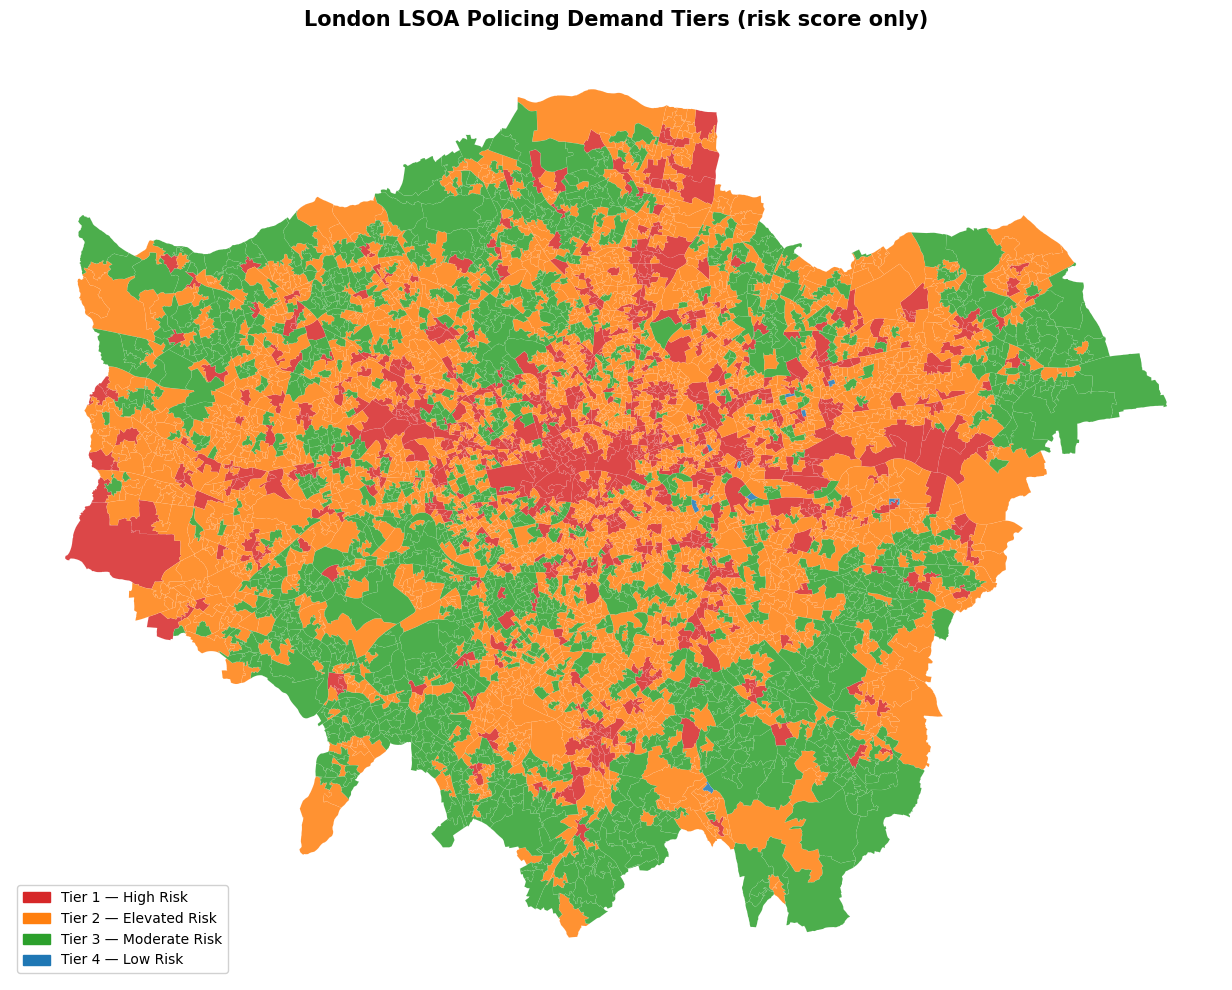

Saved: 5b_map.png


In [14]:
# Choropleth map
SHP_DIR = BASE / 'LB_shp'
gdf = pd.concat([gpd.read_file(f) for f in SHP_DIR.rglob('*.shp')], ignore_index=True)
gdf_merged = gdf.merge(risk[['lsoa21cd','tier','tier_label','risk_score_scaled']],
                        on='lsoa21cd', how='left').to_crs(epsg=4326)

fig, ax = plt.subplots(figsize=(14, 10))
for tier in sorted(risk['tier'].unique()):
    gdf_merged[gdf_merged['tier'] == tier].plot(
        ax=ax, color=TIER_COLOURS[tier], linewidth=0.05, edgecolor='white', alpha=0.85
    )
unmatched = gdf_merged[gdf_merged['tier'].isnull()]
if len(unmatched) > 0:
    unmatched.plot(ax=ax, color='#cccccc', linewidth=0.05, edgecolor='white')

patches = [
    mpatches.Patch(color=TIER_COLOURS[t], label=f'Tier {t} — {TIER_LABELS[t]}')
    for t in sorted(risk['tier'].unique())
]
ax.legend(handles=patches, loc='lower left', fontsize=10, framealpha=0.9)
ax.set_title('London LSOA Policing Demand Tiers (risk score only)',
             fontsize=15, fontweight='bold', pad=15)
ax.set_axis_off()
plt.tight_layout()
plt.savefig(OUT / '5b_map.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 5b_map.png')

## Section-6: Save Outputs

In [15]:
# Save LSOA-level assignments
out_df = risk[['lsoa21cd','lsoa21nm','lad22nm','tier','tier_label',
               'risk_score_scaled','crime_count','severity_weighted_count',
               'seasonal_volatility','stop_search_rate','employment_deprivation',
               'resolution_rate','total_footfall','silhouette']].copy()
out_df.to_parquet(OUT / 'phase5b_clusters.parquet', index=False)
print(f'Saved phase5b_clusters.parquet — {out_df.shape}')

# Save profiles
profile.to_csv(OUT / 'phase5b_cluster_profiles.csv', index=False)
print(f'Saved phase5b_cluster_profiles.csv — {profile.shape}')

Saved phase5b_clusters.parquet — (4994, 14)
Saved phase5b_cluster_profiles.csv — (4, 12)


In [16]:
print('=' * 60)
print('PHASE 5b SUMMARY — Risk Score Only Clustering')
print('=' * 60)
print(f'Total LSOAs:              {len(risk)}')
print(f'Final k (tiers):          {FINAL_K}')
print(f'Overall silhouette score: {overall_sil:.4f}')
print(f'Best k — silhouette:      {best_k_sil}')
print(f'Best k — AIC:             {best_k_aic}')
print(f'Best k — BIC:             {best_k_bic}')
print()
for _, row in profile.iterrows():
    print(f"  Tier {int(row['tier'])} — {row['tier_label']:<16}"
          f" n={int(row['n_lsoas']):5d} ({row['pct_london']:4.1f}%)"
          f" mean_risk={row['risk_score_scaled']:.1f}"
          f" mean_crimes={row['crime_count']:.0f}")
print('=' * 60)
print(f'Outputs saved to: {OUT}')

PHASE 5b SUMMARY — Risk Score Only Clustering
Total LSOAs:              4994
Final k (tiers):          4
Overall silhouette score: 0.5449
Best k — silhouette:      4
Best k — AIC:             6
Best k — BIC:             4

  Tier 1 — High Risk        n=  777 (15.6%) mean_risk=60.4 mean_crimes=1545
  Tier 2 — Elevated Risk    n= 2585 (51.8%) mean_risk=53.7 mean_crimes=454
  Tier 3 — Moderate Risk    n= 1619 (32.4%) mean_risk=47.5 mean_crimes=205
  Tier 4 — Low Risk         n=   13 ( 0.3%) mean_risk=2.1 mean_crimes=0
Outputs saved to: C:\Users\mbeck\OneDrive\Documents\CBL-16_data\outputs\phase5b
